# EXPLORATORY ANALYSIS

In [4]:
import pybedtools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pybedtools import BedTool

## 1. tf occupancy distribution

comparing distribution of tfs to see if occupancy bins are reasonable

as a sanity check, also compare against a 'null' using bedtools shuffle

In [5]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'
blacklist = 'hg38-blacklist.v2.bed.gz'

tf_df = pd.read_csv('merged_tf_counts.bed', sep = '\t', names = ['chrom', 'start', 'end', 'tfs', 'n_tfs'])

threshold = tf_df['n_tfs'].quantile(0.99)


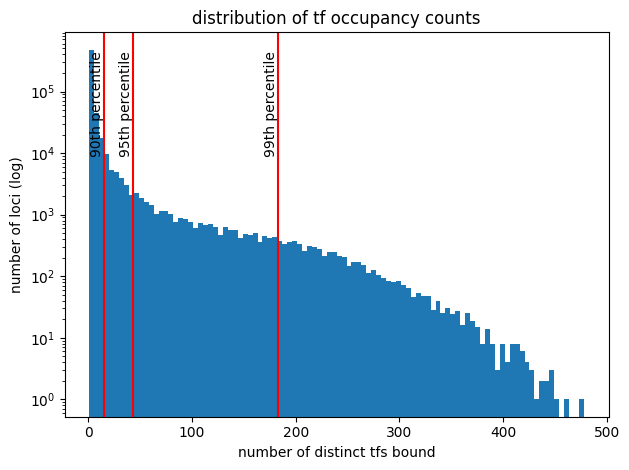

In [15]:
plt.figure()
plt.hist(tf_df['n_tfs'], bins=100)
plt.yscale('log')
plt.xlabel('number of distinct tfs bound')
plt.ylabel('number of loci (log)')
plt.title('distribution of tf occupancy counts')

# plot percentiles
for p in [90, 95, 99]:
    threshold = tf_df['n_tfs'].quantile(p/100)
    plt.axvline(threshold, color = 'red')
    plt.text(threshold,
             plt.ylim()[1]*0.5,
             f'{p}th percentile',
             rotation = 90,
             va = 'top',
             ha = 'right'
             )

plt.tight_layout()

plt.savefig('plot_tf_occupancy_distribution')

plt.show()

plots number of loci against number of distinct tfs bound,

along the bottom, is increasing number of tfs bound at specific locations, along the y axis is the number of loci which contain that number of tf binding

tells us the distribution of how tf binding is clustered at specific loci

In [10]:
tf_peak_paths = {f.split('/')[-1].replace('.bed', ''): f
                  for f in sorted(glob.glob('peaks/*.bed'))}
# print(list(tf_peak_paths.items())[:5])
print(len(tf_peak_paths), 'peak files found')

n_samples = 5
null_dfs = []

for sample in range(n_samples):
    shuffled = []
    for tf_name, path in tf_peak_paths.items():
        bed = BedTool(path) # read bed file
        shuffle = bed.shuffle(g = genome,
                              excl = blacklist,
                              chrom = True)
        tagged = shuffle.each(lambda f, name=tf_name: pybedtools.create_interval_from_list(
            [f.chrom, f.start, f.end, name]
        )).saveas()
        shuffled.append(tagged)

    combined = pybedtools.BedTool.cat(*shuffled, postmerge=False).sort(g=genome)
    merged = combined.merge(c=4, o='distinct,count_distinct')

    sample_df = merged.to_dataframe(names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
    sample_df['rep'] = sample
    null_dfs.append(sample_df)
    print(f'shuffle rep {sample}: {len(sample_df)} merged loci, max n_tfs={sample_df["n_tfs"].max()}')

null_df = pd.concat(null_dfs, ignore_index = True)




770 peak files found
shuffle rep 0: 2120683 merged loci, max n_tfs=466
shuffle rep 1: 2120058 merged loci, max n_tfs=476
shuffle rep 2: 2119698 merged loci, max n_tfs=406
shuffle rep 3: 2120789 merged loci, max n_tfs=407
shuffle rep 4: 2119575 merged loci, max n_tfs=435


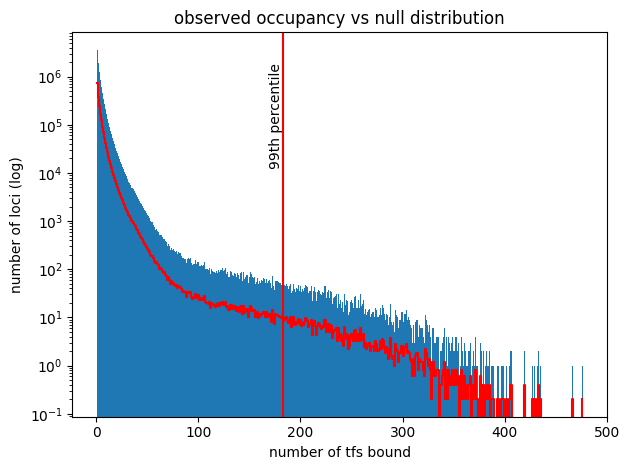

In [13]:
max_count = max(null_df['n_tfs'].max(), null_df['n_tfs'].max())
bins = np.arange(1, max_count +2) - 0.5

plt.figure()
plt.hist(null_df['n_tfs'],
         bins = bins,
         label = 'observed')

null_counts, _ = np.histogram(null_df['n_tfs'], bins=bins)
null_counts_scaled = null_counts / n_samples
bin_centres = (bins[:-1] + bins[1:]) / 2
plt.step(bin_centres, null_counts_scaled, 
         where = 'mid', 
         color = 'red', 
         label = 'null')

for p in [99]:
    threshold = tf_df['n_tfs'].quantile(p/100)
    plt.axvline(threshold, color = 'red')
    plt.text(threshold,
             plt.ylim()[1]*0.5,
             f'{p}th percentile',
             rotation = 90,
             va = 'top',
             ha = 'right'
             )

plt.yscale('log')
plt.xlabel('number of tfs bound')
plt.ylabel('number of loci (log)')
plt.title('observed occupancy vs null distribution')
plt.tight_layout()
# plt.savefig('plot_observed_occupancy_vs_shuffled_null')
plt.show()

## 2 histone mark peak study

load peak widths

In [8]:
peak_files = {
    "H3K4me3": "K562_H3K4me3.bed",
    "H3K27ac": "K562_H3K27ac.bed",
    "H3K27me3": "K562_H3K27me3.bed",
    "H3K9me3": "K562_H3K9me3.bed",
    # "H3K4me3 olly": "olly_files/H3K4me3.bed",
    # "H3K27me3 olly": "olly_files/H3K27me3.bed",
    "random tf 1": "peaks/ADNP_ENCSR440VKE.bed",
    "random tf 2": "peaks/AFF1_ENCSR241LIH.bed", 
    "random tf 3": "peaks/AFF1_ENCSR426URK.bed",
    "random tf 4": "peaks/AFF4_ENCSR436CZV.bed"
}

widths = []
for mark, path in peak_files.items():
    bt = BedTool(path)
    widths.extend({'mark': mark,
                   'width': iv.length}
                   for iv in bt)
df = pd.DataFrame(widths)

summary = df.groupby("mark")["width"].describe(percentiles=[.25, .5, .75])
print(summary[["50%", "25%", "75%", "min", "max"]])

                50%    25%     75%    min      max
mark                                              
H3K27ac       529.0  324.0   991.0  160.0  13924.0
H3K27me3      644.0  456.0  1016.0  295.0  30281.0
H3K4me3      1181.0  515.0  2139.0  220.0  11227.0
H3K9me3       212.0  163.0   292.0  130.0   4655.0
random tf 1   830.0  830.0   830.0  208.0   1585.0
random tf 2   464.0  464.0   464.0  116.0   6015.0
random tf 3   460.0  460.0   460.0  115.0   6138.0
random tf 4   670.0  670.0   670.0  168.0   1291.0


peak width distribution

/var/folders/1s/vxhn8sp17fqfjy17x9njtp_w0000gn/T/ipykernel_16562/3688983660.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_mark, labels = marks, showfliers= False)


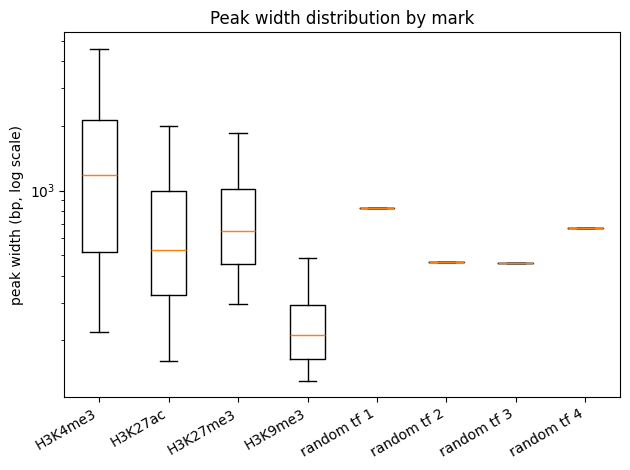

In [9]:
marks = df["mark"].unique()
data_by_mark = [df.loc[df["mark"] == m, "width"].values for m in marks]

fig, ax = plt.subplots()
ax.boxplot(data_by_mark, labels = marks, showfliers= False)
plt.xticks(rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("peak width (bp, log scale)")
ax.set_title("Peak width distribution by mark")
plt.tight_layout()
plt.savefig("plot_peak_widths.png")
plt.show()

cdf of peak width

In [ ]:
fig, ax = plt.subplots()
for mark, sub in df.groupby("mark"):
    w_sorted = np.sort(sub["width"].values)
    cdf = np.arange(1, len(w_sorted) + 1) / len(w_sorted)
    ax.plot(w_sorted, cdf, label=mark)

ax.set_xscale("log")
ax.set_xlabel("peak width (bp, log scale)")
ax.set_ylabel("cumulative fraction of peaks")
ax.set_title("Empirical CDF of peak width")
ax.legend()
plt.tight_layout()
plt.savefig("peak_width_cdf.png", dpi=300)
plt.show()